## Analise A/B

Importar Bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


# Carregar Dataset

In [2]:
df = pd.read_csv('ab_data.csv',
    sep=',' ,
    encoding='latin-1',
    skiprows=0
)
print("✅ Dataset carregado com Sucesso")

✅ Dataset carregado com Sucesso


In [3]:
print(f'Linhas: {df.shape[0]:,}')
print(f'Colunas: {df.shape[1]}')

Linhas: 294,478
Colunas: 5


In [4]:
df.head(10)

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1
5,936923,2017-01-10 15:20:49.083499,control,old_page,0
6,679687,2017-01-19 03:26:46.940749,treatment,new_page,1
7,719014,2017-01-17 01:48:29.539573,control,old_page,0
8,817355,2017-01-04 17:58:08.979471,treatment,new_page,1
9,839785,2017-01-15 18:11:06.610965,treatment,new_page,1


## Verificação inicial do DataFrame

In [5]:
df.info() #Exibe informações sobre o Dataframe

print(f'-'*50)

df.dtypes #Exibe informações sobre as colunas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB
--------------------------------------------------


user_id          int64
timestamp       object
group           object
landing_page    object
converted        int64
dtype: object

In [6]:
df['data'] = pd.to_datetime(df['timestamp'])

print(f"Tipo da coluna DATA: {df['data'].dtype}")
print(f"Data mais antiga: {df['data'].min()}")
print(f"Data mais recente: {df['data'].max()}")

Tipo da coluna DATA: datetime64[ns]
Data mais antiga: 2017-01-02 13:42:05.378582
Data mais recente: 2017-01-24 13:41:54.460509


In [7]:
df.dtypes

user_id                  int64
timestamp               object
group                   object
landing_page            object
converted                int64
data            datetime64[ns]
dtype: object

In [8]:
n1 = df[(df['group'] == 'control') & (df['landing_page'] == 'new_page')]
n1.head()


,user_id,timestamp,group,landing_page,converted,data
22,767017,2017-01-12 22:58:14.991443,control,new_page,0,2017-01-12 22:58:14.991443
240,733976,2017-01-11 15:11:16.407599,control,new_page,0,2017-01-11 15:11:16.407599
490,808613,2017-01-10 21:44:01.292755,control,new_page,0,2017-01-10 21:44:01.292755
846,637639,2017-01-11 23:09:52.682329,control,new_page,1,2017-01-11 23:09:52.682329
850,793580,2017-01-08 03:25:33.723712,control,new_page,1,2017-01-08 03:25:33.723712


In [9]:
# Quantidades de divergentias encontradas na primeira situação
print(f'Foram encontradas {len(n1)} ocorrências')

Foram encontradas 1928 ocorrências


In [10]:
n2 = df[(df['group'] == 'treatment') & (df['landing_page'] == 'old_page')]
n2.head()

,user_id,timestamp,group,landing_page,converted,data
308,857184,2017-01-20 07:34:59.832626,treatment,old_page,0,2017-01-20 07:34:59.832626
327,686623,2017-01-09 14:26:40.734775,treatment,old_page,0,2017-01-09 14:26:40.734775
357,856078,2017-01-12 12:29:30.354835,treatment,old_page,0,2017-01-12 12:29:30.354835
685,666385,2017-01-23 08:11:54.823806,treatment,old_page,0,2017-01-23 08:11:54.823806
713,748761,2017-01-10 15:47:44.445196,treatment,old_page,0,2017-01-10 15:47:44.445196


In [11]:
# Quantidades de divergentias encontradas na segunda situação
print(f'Foram encontradas {len(n2)} ocorrências')

Foram encontradas 1965 ocorrências


Verificar a quantidade em % de dados inconsistentes (errados)

In [12]:
n0 = (len(n1)+len(n2))/len(df) * 100
print(f'Há aproximadamente {n0:.2f}% de Dados Inconsistentes identificados no DataFrame')

Há aproximadamente 1.32% de Dados Inconsistentes identificados no DataFrame


Remover as linhas inconsistentes do DataFrame

Abaixo a lógica para isso, e criar o DataFrame correspondente a limpeza


In [14]:
# Cria o novo DF limpo
df_limpo = df[(df['group'] == 'control') & (df['landing_page'] == 'old_page') | 
   (df['group'] == 'treatment') & (df['landing_page'] == 'new_page')]


df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 290585 entries, 0 to 294477
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       290585 non-null  int64         
 1   timestamp     290585 non-null  object        
 2   group         290585 non-null  object        
 3   landing_page  290585 non-null  object        
 4   converted     290585 non-null  int64         
 5   data          290585 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 15.5+ MB


In [15]:
# Ve a proporção de distribuição dos dois tipos de grupo

# maneira 1
df_limpo['group'].value_counts(normalize=True) * 100

group
treatment    50.006366
control      49.993634
Name: proportion, dtype: float64

In [16]:
# maneira 2
contagem = df_limpo['group'].value_counts()  
print(contagem)
print(contagem / contagem.sum() * 100)

group
treatment    145311
control      145274
Name: count, dtype: int64
group
treatment    50.006366
control      49.993634
Name: count, dtype: float64


In [17]:
# maneira 3
pd.DataFrame({
    'contagem': df_limpo['group'].value_counts(),
    'percentual': df_limpo['group'].value_counts(normalize=True) * 100
})  

,contagem,percentual
group,,
treatment,145311,50.006366
control,145274,49.993634


### Calcular a taxa de conversão por grupo

In [18]:
df_limpo.groupby('group')['converted'].mean()

group
control      0.120386
treatment    0.118807
Name: converted, dtype: float64

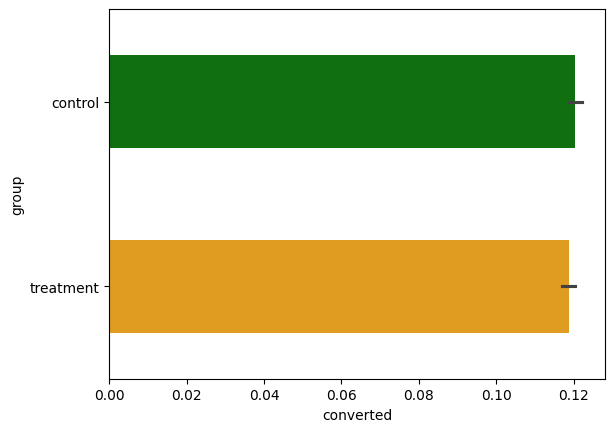

In [28]:
sns.barplot(x='converted', y='group', data=df_limpo, hue='group', legend=False, palette=['green', 'orange'], width=0.5)
plt.show()

### Verificar se tem usuários duplicados

In [35]:
#Verifica a existencia de usuários duplicados

duplicados = df_limpo['user_id'].duplicated().sum()
print(f'Foi encontrado {duplicados} usuário(s) duplicado(s)')

Foi encontrado 1 usuário(s) duplicado(s)


In [38]:
# Mostra qual é
df_limpo[df_limpo['user_id'].duplicated(keep=False)]

,user_id,timestamp,group,landing_page,converted,data
1899,773192,2017-01-09 05:37:58.781806,treatment,new_page,0,2017-01-09 05:37:58.781806
2893,773192,2017-01-14 02:55:59.590927,treatment,new_page,0,2017-01-14 02:55:59.590927


Apesar de ser o mesmo usuário, as entradas são em **datas diferentes**, portanto para essa análise equivale como métrica

In [45]:
# Calular a taxa de conversão a partir da coluna data, extraindo somente o dia (dt.date)

df_limpo.groupby(['group', df_limpo['data'].dt.date])['converted'].mean()



group      data      
control    2017-01-02    0.125568
           2017-01-03    0.113809
           2017-01-04    0.121922
           2017-01-05    0.123230
           2017-01-06    0.115350
           2017-01-07    0.120987
           2017-01-08    0.118887
           2017-01-09    0.119644
           2017-01-10    0.112864
           2017-01-11    0.118870
           2017-01-12    0.122048
           2017-01-13    0.116911
           2017-01-14    0.126756
           2017-01-15    0.120494
           2017-01-16    0.121833
           2017-01-17    0.122865
           2017-01-18    0.124807
           2017-01-19    0.119945
           2017-01-20    0.115243
           2017-01-21    0.125945
           2017-01-22    0.119163
           2017-01-23    0.125670
           2017-01-24    0.118007
treatment  2017-01-02    0.119874
           2017-01-03    0.113781
           2017-01-04    0.116649
           2017-01-05    0.114988
           2017-01-06    0.123462
           2017-01-07    0

In [51]:
# Mesma informação agora rearranjados (unstack) 
# Transforma um dos niveis do indice em colunas

conversao_dia = df_limpo.groupby(['group', df_limpo['data'].dt.date])['converted'].mean().unstack(level=0)
print(conversao_dia)

group        control  treatment
data                           
2017-01-02  0.125568   0.119874
2017-01-03  0.113809   0.113781
2017-01-04  0.121922   0.116649
2017-01-05  0.123230   0.114988
2017-01-06  0.115350   0.123462
2017-01-07  0.120987   0.116205
2017-01-08  0.118887   0.120746
2017-01-09  0.119644   0.118065
2017-01-10  0.112864   0.126344
2017-01-11  0.118870   0.115091
2017-01-12  0.122048   0.122344
2017-01-13  0.116911   0.111248
2017-01-14  0.126756   0.119242
2017-01-15  0.120494   0.113452
2017-01-16  0.121833   0.119175
2017-01-17  0.122865   0.127256
2017-01-18  0.124807   0.124792
2017-01-19  0.119945   0.117216
2017-01-20  0.115243   0.117682
2017-01-21  0.125945   0.115701
2017-01-22  0.119163   0.118009
2017-01-23  0.125670   0.121061
2017-01-24  0.118007   0.121706


<Axes: xlabel='data'>

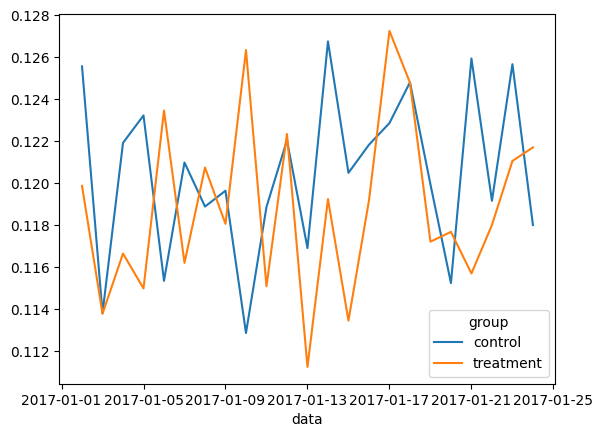

In [ ]:
conversao_dia.plot() # Usando o método plot do Pandas

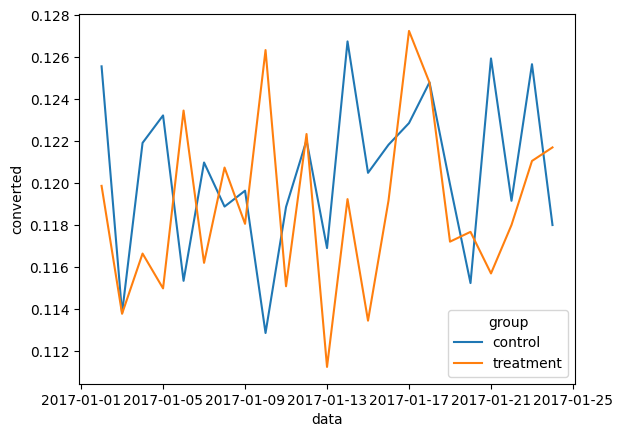

In [60]:
# Plotando no Seaborn direto, não precisa calcular a média

sns.lineplot(x=df_limpo['data'].dt.date, y='converted', hue='group', data=df_limpo, errorbar=None)
plt.show()

O grafico demonstra que ambas as landing pages converteram parecido, reforçando os numeros já descritos

### Criar uma amostra com 5000 entradas

In [66]:
# Visualizar a amostragem no DF 

df_limpo.sample(n=5000, random_state=42)

,user_id,timestamp,group,landing_page,converted,data
283578,650999,2017-01-23 11:13:55.254362,treatment,new_page,1,2017-01-23 11:13:55.254362
212224,705130,2017-01-14 12:04:59.832693,treatment,new_page,0,2017-01-14 12:04:59.832693
220197,748972,2017-01-09 15:35:11.198128,treatment,new_page,0,2017-01-09 15:35:11.198128
235558,823750,2017-01-08 19:46:34.616589,treatment,new_page,0,2017-01-08 19:46:34.616589
182233,931384,2017-01-11 06:36:43.921872,control,old_page,0,2017-01-11 06:36:43.921872
...,...,...,...,...,...,...
31189,669886,2017-01-15 02:53:43.741763,control,old_page,0,2017-01-15 02:53:43.741763
158624,925326,2017-01-10 11:41:21.279497,control,old_page,0,2017-01-10 11:41:21.279497
266410,749228,2017-01-17 21:03:10.584885,treatment,new_page,0,2017-01-17 21:03:10.584885
120432,818738,2017-01-20 12:45:37.067228,control,old_page,0,2017-01-20 12:45:37.067228


In [77]:
amostra = df_limpo.sample(n=5000, random_state=42) # Salva numa variavel

In [78]:
amostra.info() # Verifica o DataFrame

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 283578 to 56940
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       5000 non-null   int64         
 1   timestamp     5000 non-null   object        
 2   group         5000 non-null   object        
 3   landing_page  5000 non-null   object        
 4   converted     5000 non-null   int64         
 5   data          5000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 273.4+ KB


Verificar a proporção da amostra

In [79]:
taxa_amostragem = amostra['group'].value_counts()  
print(taxa_amostragem)
print(taxa_amostragem / taxa_amostragem.sum() * 100)

group
control      2509
treatment    2491
Name: count, dtype: int64
group
control      50.18
treatment    49.82
Name: count, dtype: float64


*No caso manteve praticamente as condições iniciais do DataFrame inteiro*

### Separar os dados de conversão de cada grupo para alimentar o teste estatístico

In [82]:
amostra_control = amostra[amostra['group'] == 'control']['converted']
amostra_control

182233    0
132654    1
193211    0
287045    0
785       0
         ..
218515    0
31189     0
158624    0
120432    0
56940     0
Name: converted, Length: 2509, dtype: int64

In [83]:
amostra_treatment = amostra[amostra['group'] == 'treatment']['converted']
amostra_treatment

283578    1
212224    0
220197    0
235558    0
101118    0
         ..
49573     0
92037     0
281211    1
246123    1
266410    0
Name: converted, Length: 2491, dtype: int64

## Inserindo as amostras retiradas e comparando no teste Bicaudal

In [90]:
t_stat, p_valor = stats.ttest_ind(amostra_control, amostra_treatment) # Cria e separa em 2 variáveis
print(f'Estatistica t:{t_stat:.4f}')
print(f'P-valor:{p_valor:.4f}')


Estatistica t:-1.5837
P-valor:0.1133


## Conclusões:
Teste de hipóteses (teste t bicaudal):

H0: Não há diferença significativa entre as taxas de conversão;

H1: Há diferença significativa entre as taxas de conversão;

Amostra utilizada: 5.000 registros;

Estatistica t: -1.5837;

P-valor: 0.1133 (acima do nivel de significancia de 0.05);

___

**Não ha evidencia estatística suficiente para rejeitar a hipotese nula. A diferenca entre as taxas de conversão dos dois grupos não é significativa, indicando que o sistema de recomendação  não demonstrou impacto mensurável nas conversões. A recomendação seria <u>manter a página atual</u>.**